In [1]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89




def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err


image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}
catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]
print(catalog.colnames)


f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


num_sources = len(catalog)

from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = CT06_MWLoc()
def plot_extvec_cmd(ax, color1, mag1, ext=CT06_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None, fontsize=15):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y), fontsize=15,
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    if label is not None:
        ax.plot([], [], color=color, marker='>', markersize=8,
                label=f'{label}', linestyle='-', linewidth=2)

    else:
        ax.plot([], [], color=color, marker='>', markersize=8,
                linestyle='-', linewidth=2)

imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
mags = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(mags.keys())




['skycoord_ref', 'skycoord_ref_filtername', 'sep_f140m', 'id_f140m', 'skycoord_f140m', 'flux_fit_f140m', 'flux_err_f140m', 'mask_f140m', 'qfit_f140m', 'cfit_f140m', 'local_bkg_f140m', 'roundness1_f140m', 'roundness2_f140m', 'sharpness_f140m', 'from_sat_catalog_f140m', 'std_ra_f140m', 'std_dec_f140m', 'nmatch_f140m', 'nmatch_good_f140m', 'flux_err_prop_f140m', 'sep_f162m', 'id_f162m', 'skycoord_f162m', 'flux_fit_f162m', 'flux_err_f162m', 'mask_f162m', 'qfit_f162m', 'cfit_f162m', 'local_bkg_f162m', 'roundness1_f162m', 'roundness2_f162m', 'sharpness_f162m', 'from_sat_catalog_f162m', 'std_ra_f162m', 'std_dec_f162m', 'nmatch_f162m', 'nmatch_good_f162m', 'flux_err_prop_f162m', 'sep_f182m', 'id_f182m', 'skycoord_f182m', 'flux_fit_f182m', 'flux_err_f182m', 'mask_f182m', 'qfit_f182m', 'cfit_f182m', 'local_bkg_f182m', 'roundness1_f182m', 'roundness2_f182m', 'sharpness_f182m', 'from_sat_catalog_f182m', 'std_ra_f182m', 'std_dec_f182m', 'nmatch_f182m', 'nmatch_good_f182m', 'flux_err_prop_f182m', 's

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


7.524944249956756e-11 deg2
7.527757763662479e-11 deg2


Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:06:02.819' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T14:19:01.510' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.130' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220310 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512065.053 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


7.524953554552339e-11 deg2
7.524998291846055e-11 deg2
3.05383490572652e-10 deg2


...

Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2024-09-0

3.0546256511446897e-10 deg2
9.491459138193236e-10 deg2
9.491652259572426e-10 deg2
9.491458943030916e-10 deg2
9.491652069110604e-10 deg2


Set DATE-AVG to '2024-09-08T11:31:04.265' from MJD-AVG.
Set DATE-END to '2024-09-08T12:43:52.463' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.803760 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291894033.527 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2024-09-08T11:39:49.277' from MJD-AVG.
Set DATE-END to '2024-09-08T12:52:42.510' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.797166 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291845460.779 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-09-08T11:47:44.336' from MJD-AVG.
Set DATE-END to '2024-09-08T13:00:37.070' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.791203 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291801554.144 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '

9.491651972183757e-10 deg2
7.524426796552275e-11 deg2


Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [2]:
def get_line_excess(catalog, narrow, wide):
    # --- Convert catalog MJy/sr → Jy ---
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))

    data_narrow = (catalog['flux_fit_' + narrow] * u.MJy/u.sr *
                   ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    data_wide = (catalog['flux_fit_' + wide] * u.MJy/u.sr *
                 ww_wide.proj_plane_pixel_area()).to(u.Jy)

    # --- Load filter curves ---
    tab_n = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    tab_w = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    wave_n = tab_n['Wavelength'] * u.AA
    trans_n = tab_n['Transmission']

    wave_w = tab_w['Wavelength'] * u.AA
    trans_w = tab_w['Transmission']

    # --- Interpolate narrow onto wide grid ---
    trans_n_interp = np.interp(wave_w.value, wave_n.value, trans_n)

    # --- Fractional overlap (proper integral) ---
    num = np.trapezoid(
    (trans_w / trans_w.max()) * (trans_n_interp / trans_n.max()),
    wave_w.value
    )
    den = np.trapezoid(trans_w / trans_w.max(), wave_w.value)
    f = num / den

    if np.isclose(f, 1.0):
        return None, None

    # --- Continuum & line (still in Jy = F_nu) ---
    cont_nu = (data_wide - data_narrow * f) / (1 - f)
    line_nu = data_narrow - cont_nu

    width_narrow = np.trapezoid(trans_n / trans_n.max(), wave_n.value) * u.AA

    # --- Equivalent Width ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ew = (line_nu / cont_nu) * width_narrow

    return line_nu.value, ew.to_value(u.AA)

paa_excess,  paa_excess_ew = get_line_excess(catalog, 'f187n', 'f182m')
bra_excess,  bra_excess_ew = get_line_excess(catalog, 'f405n', 'f410m')






Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T13:24:26.757' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.021' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202550 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191894.941 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [3]:

def get_av(color, mag, ext=CT06_MWLoc(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params
    print('color1:', color1, 'mag1:', mag1)

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5
parsec_mags = {
    'f140m': F140Mmag_av0,
    'f162m': F162Mmag_av0,
    'f182m': F182Mmag_av0,
    'f210m': F210Mmag_av0,
    'f335m': F335Mmag_av0,
    'f360m': F360Mmag_av0,
    'f410m': F410Mmag_av0,
    'f480m': F480Mmag_av0,
}
age_idx = logage_av0 == 6

idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
f162 = f162m_mag[0].to_value(u.mag)
f210 = f210m_mag[0].to_value(u.mag)
f360 = f360m_mag[0].to_value(u.mag)
f480 = f480m_mag[0].to_value(u.mag)
isochrone_x_start = parsec_mags['f162m'][age_idx][idx_01msun] - parsec_mags['f210m'][age_idx][idx_01msun]
isochrone_x_end = parsec_mags['f162m'][age_idx][idx_20msun] - parsec_mags['f210m'][age_idx][idx_20msun]
isochrone_y_start = parsec_mags['f162m'][age_idx][idx_01msun]
isochrone_y_end = parsec_mags['f162m'][age_idx][idx_20msun]

color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start
av_estimate = get_av(f162m_mag[0].value - f210m_mag[0].value, f162m_mag[0].value, ext=CT06_MWLoc(), color1=('f162m', 'f210m'), mag1=('f162m',), isochrone_line_params=(color_slope, color_intercept))


 col1    col2  col3      col4          col5       col6   col7   col8   col9  col10 col11 col12   col13  col14  col15  col16  col17  col18   col19   col20   col21   col22    col23     col24     col25   col26   col27   col28   col29   col30   col31   col32   col33   col34   col35   col36   col37   col38   col39   col40   col41   col42   col43   col44   col45   col46   col47   col48   col49   col50 
------ ------- ---- -------------- ------------ ------- ------ ------ ------ ----- ----- ------ ------- ------ ------ ------ ------ ----- --------- ----- --------- ------ --------- --------- --------- ------ ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- -------
0.0207 0.15867  5.0   0.0908484459 1.0897678296   0.091  -0.78 3.4382  2.881     0   0.0  0.545     0.0    0.0    0.0    0.0    0.0    -1 -2.54e-13   0.0    0.6936 0.2855  0.003749  0.001011  0.009172

 col1    col2  col3      col4          col5       col6   col7   col8   col9  col10 col11 col12   col13  col14  col15  col16  col17  col18   col19   col20   col21   col22    col23     col24     col25   col26   col27   col28   col29   col30   col31   col32   col33   col34   col35   col36   col37   col38   col39   col40   col41   col42   col43   col44   col45   col46   col47   col48   col49   col50 
------ ------- ---- -------------- ------------ ------- ------ ------ ------ ----- ----- ------ ------- ------ ------ ------ ------ ----- --------- ----- --------- ------ --------- --------- --------- ------ ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- -------
0.0207 0.15867  5.0   0.0908484459 1.0897678296   0.091  -0.78 3.4382  2.881     0   0.0  0.545     0.0    0.0    0.0    0.0    0.0    -1 -2.54e-13   0.0    0.6936 0.2855  0.003749  0.001011  0.009172

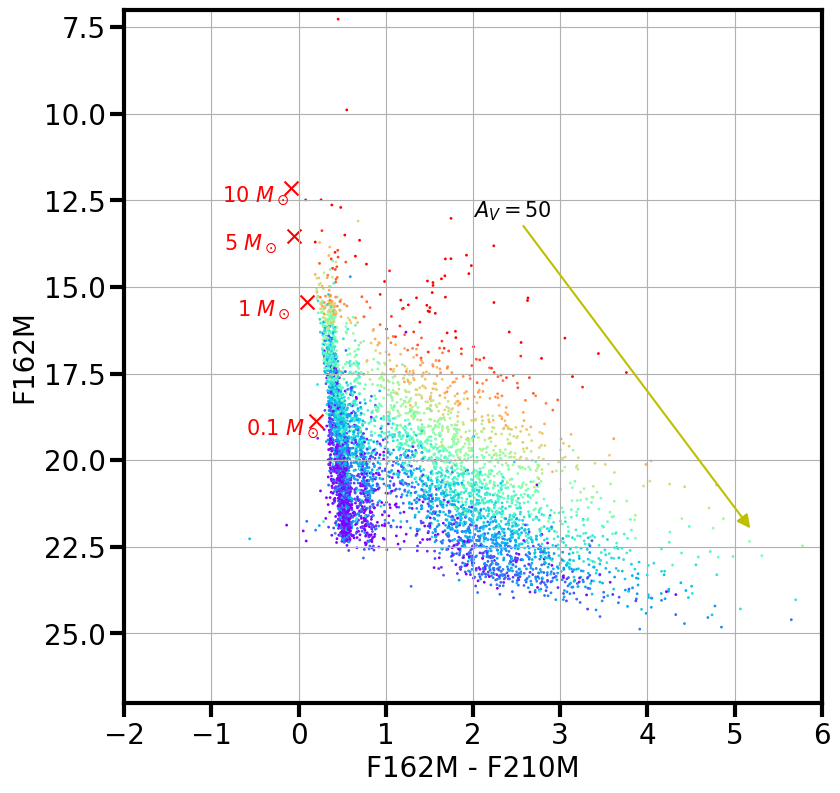

In [4]:
import matplotlib as mpl
from matplotlib.path import Path
from astropy.table import Table
import crds
from matplotlib.colors import LogNorm
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5

plt.rcParams['axes.labelsize']=20 
plt.rcParams['xtick.labelsize']=20
plt.rcParams['ytick.labelsize']=20
plt.rcParams['axes.titlesize']=20
mpl.rcParams['axes.linewidth'] = 3
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 3
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 3


color_for_points = paa_excess
norm = LogNorm(vmin=1e-7, vmax=1e-4)
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111)
ax.scatter(f162m_mag[0] - f210m_mag[0], f162m_mag[0], s=1,  c=color_for_points, alpha=1, norm=norm, cmap='rainbow')

age_idx = logage_av0 == 6
#ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx], F162Mmag_av0[age_idx],c='r')
cmap = plt.get_cmap('rainbow')

ext = CT06_MWLoc()
#plot isochrone with Av=10
#ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx]  + (ext(1/1.62/u.um) - ext(1/2.10/u.um))*5,
#F162Mmag_av0[age_idx]+(ext(1/1.62/u.um))*5, color='g')
#ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx]  + (ext(1/1.62/u.um) - ext(1/2.10/u.um))*10, 
#F162Mmag_av0[age_idx]+(ext(1/1.62/u.um))*10, color='b')

idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
print(F162Mmag_av0)
print('age_idx:', age_idx, 'idx_01msun:', idx_01msun, 'idx_20msun:', idx_20msun)
isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isocrhone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isocrhone_y_end = F162Mmag_av0[age_idx][idx_20msun]
color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isocrhone_y_start - color_slope * isochrone_x_start

A_K_scale = 5
A_V_scale = A_K_scale * 10
#ax.plot([isochrone_x_start, isochrone_x_end], [isocrhone_y_start, isocrhone_y_end], color='r', linestyle='--')
#ax1.plot([isochrone_x_start+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*A_V_scale, isochrone_x_end+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*A_V_scale], 
#[isocrhone_y_start+(ext(1/1.82/u.um))*A_V_scale, isocrhone_y_end+(ext(1/1.82/u.um))*A_V_scale], color='r', linestyle='--')
# extrapolate the linear part of the isochrone to the left and right by 0.5 mag in color

# and plot
#x_vals = np.array([-1, 2])
#y_vals = color_slope * x_vals + color_intercept
#ax.plot(x_vals, y_vals, color='r', linestyle='--')
for mass in [0.1, 1, 5, 10]:
    idx_mass = np.argmin(np.abs(mass_av0[age_idx]-mass))
    ax.scatter(F162Mmag_av0[age_idx][idx_mass] - F210Mmag_av0[age_idx][idx_mass], F162Mmag_av0[age_idx][idx_mass], color='r', marker='x', s=100)
    ax.annotate(f'{mass} $M_\odot$', (F162Mmag_av0[age_idx][idx_mass] - F210Mmag_av0[age_idx][idx_mass], F162Mmag_av0[age_idx][idx_mass]), textcoords="offset points", xytext=(-50,-10), ha='left', color='r', fontsize=15)
plot_extvec_cmd(ax, ('f162m', 'f210m'), ('f162m',), extvec_scale=50, start=(2,13))

#ax.text(-0.2, 11, r'$A_V$=0', fontsize=15, color='r')
#ax.text(0.1, 12, r'$A_V$=5', fontsize=15, color='g')
#ax.text(0.5, 13, r'$A_V$=10', fontsize=15, color='b')


#ax.text(1.7, 26.5, 'embedded sources in W51', fontsize=15, color='k')
#ax.text(-1.6, 26.5, 'foreground sources', fontsize=15, color='k')
#ax.annotate('embedded sources in W51', xy=(2, 26.5), xytext=(1.4, 26.5), ha='left', color='k', fontsize=15)
#ax.annotate('foreground sources', xy=(0, 26.5), xytext=(1, 26.5), ha='left', color='k', fontsize=15)
#ax.plot([0.4,1.3], [7, 27], c='k', ls='dashed')
# add colorbar as inset


ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
ax.set_ylim(27,7)
ax.set_xlim(-2,6)
ax.grid()
plt.show()





In [5]:


from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

def robust_gp_surface(x, y, z,
                      sigma_clip=3,
                      max_iter=5):

    #--------------------------------------------
    # Fit in log space
    #--------------------------------------------
    zlog = np.log10(z)

    X = np.column_stack((x, y))

    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * RBF(length_scale=[1.0, 1.0],
              length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(1e-3)
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10
    )

    good = np.ones(len(z), dtype=bool)

    for i in range(max_iter):

        gp.fit(X[good], zlog[good])

        model = gp.predict(X)

        resid = zlog - model

        # robust scatter from inliers
        sigma = 1.4826 * np.median(
            np.abs(resid[good] - np.median(resid[good]))
        )

        # remove only positive excesses
        new_good = resid < sigma_clip * sigma

        if np.all(new_good == good):
            break

        good = new_good

    return gp, good

y = f162m_mag[0].value
x = f162m_mag[0].value - f210m_mag[0].value
z= paa_excess
mask = (av_estimate > 12) & np.isfinite(x) & np.isfinite(y) & np.isfinite(z) & (z>0)
x= x[mask]
y= y[mask]
z= z[mask]
gp, good = robust_gp_surface(x, y, z)
X = np.column_stack((x, y))

log_model = gp.predict(X)
model = 10**log_model

excess = z - model


In [11]:



xx = np.linspace(x.min(), x.max(), 200)
yy = np.linspace(12, 25, 200)

XX, YY = np.meshgrid(xx, yy)

grid = np.column_stack((XX.ravel(), YY.ravel()))

log_surface = gp.predict(grid)

surface = 10**log_surface
surface = surface.reshape(XX.shape)

fig = plt.figure(figsize=(14,21))
ax1 = fig.add_subplot(321)
ax1.scatter(x, y, s=10, c=z, alpha=0.5, norm=LogNorm(vmin=1e-7, vmax=1e-4), cmap='rainbow')
ax1.set_xlabel('F162M - F210M')
ax1.set_ylabel('F162M')
ax1.set_ylim(25,12)
ax1.set_xlim(0.5,6)


ax2 = fig.add_subplot(322)
c = ax2.pcolormesh(XX, YY, surface, cmap='rainbow', norm=LogNorm(vmin=1e-7, vmax=1e-4))
ax2.set_xlabel('F162M - F210M')
ax2.set_ylabel('F162M')
ax2.set_ylim(25,12)
ax2.set_xlim(0.5,6)

ax3 = fig.add_subplot(323)
c = ax3.pcolormesh(XX, YY, surface, cmap='rainbow', norm=LogNorm(vmin=1e-7, vmax=1e-4))
ax3.scatter(x, y, s=10, c=z, edgecolor='black', linewidth=0.5, alpha=0.5, norm=LogNorm(vmin=1e-7, vmax=1e-4), cmap='rainbow')
ax3.set_xlabel('F162M - F210M')
ax3.set_ylabel('F162M')
ax3.set_ylim(25,12)


ax3.set_xlim(0.5,6)

ax4 = fig.add_subplot(324)
# subtract the model from the data
excess = z - model
ax4.scatter(x, y, s=10, c=excess, alpha=0.5, norm=LogNorm(vmin=1e-7, vmax=1e-4), cmap='rainbow')
ax4.set_xlabel('F162M - F210M')
ax4.set_ylabel('F162M')
ax4.set_ylim(25,12)
ax4.set_xlim(0.5,6)

ax5 = fig.add_subplot(325)

res_percent = excess / model 






ax5.scatter(x, y, s=10, c=res_percent, alpha=0.5, norm=LogNorm(vmin=np.nanmin(res_percent), vmax=np.nanmax(res_percent)), cmap='rainbow')
ax5.set_xlabel('F162M - F210M')
ax5.set_ylabel('F162M')
ax5.set_ylim(25,12)
ax5.set_xlim(0.5,6)


cbar = fig.colorbar(c, ax=[ax1, ax2, ax3, ax4, ax5], orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label(r'Pa$\alpha$ excess (Jy)', fontsize=20)

#save excess and normalized excess to file
tab_bra = Table()
tab_bra['excess'] = excess
tab_bra['normalized_excess'] = normalized_excess
tab_bra.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/pa_alpha_excess.fits', overwrite=True)




Error in callback <function _draw_all_if_interactive at 0x14ba4842f740> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 1400x2100 with 6 Axes>

In [7]:
dd

NameError: name 'dd' is not defined

Text(0, 0.5, 'Number of sources')

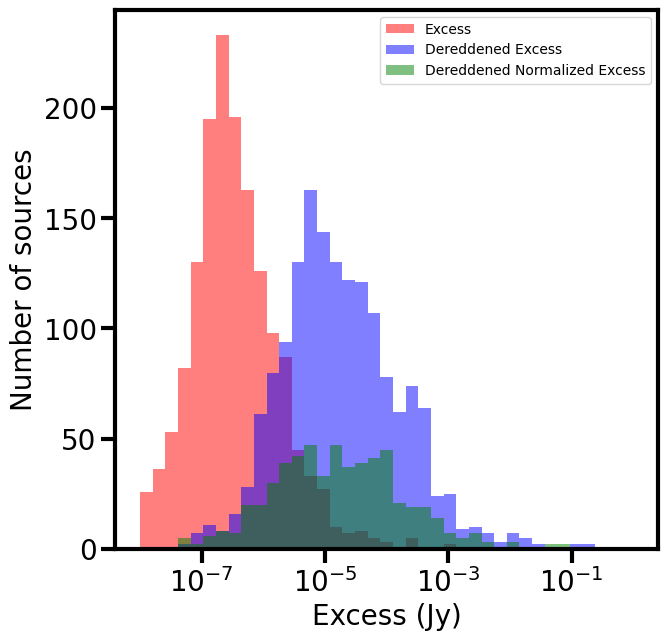

In [ ]:
# histogram of excess
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)

ax.hist(excess, bins=np.logspace(-8, 0, 40), color='r', alpha=0.5, label='Excess')
dereddend_excess = excess * 10**(0.4*av_estimate[mask]*ext(1/1.87/u.um))
dereddend_normalized_excess = normalized_excess * 10**(0.4*av_estimate[mask]*ext(1/1.87/u.um))
ax.hist(dereddend_excess, bins=np.logspace(-8, 0, 40), color='b', alpha=0.5, label='Dereddened Excess')
ax.hist(dereddend_normalized_excess, bins=np.logspace(-8, 0, 40), color='g', alpha=0.5, label='Dereddened Normalized Excess')
ax.legend()
ax.set_xscale('log')
ax.set_xlabel('Excess (Jy)')
ax.set_ylabel('Number of sources')

fwhm_f187n: 0.064 arcsec
fwhm_f187n_au: 345.6 AU
delta_lam: 236.59542237910327 Angstrom
density_from_paa: [            nan             nan  51000.72623835 ... 303527.50039893
 257876.33014116             nan] 1 / cm3
Q_from_density: [        nan         nan 44.59103853 ... 46.1402819  45.99870877
         nan]


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/tmp/ipykernel_3958372/3974386064.py:36: RuntimeWarning: invalid value encountered in log10
  ax0.hist(np.log10(EM_from_IPaa.value),bins=np.linspace(np.nanmin(np.log10(EM_from_IPaa.value)), np.nanmax(np.log10(EM_from_IPaa.value)), 20), color='g', alpha=0.5)
/tmp/ipykernel_3958372/3974386064.py:45: RuntimeWarning: invalid value encountered in log10
  ax3.hist(np.log10(I_paa.value),bins=np.linspace(np.nanmin(np.log10(I_paa.value)), np.nanmax(np.log10(I_paa.value)), 20), color='m', alpha=0.5)


Text(0.5, 0, 'log10(I) [erg/s/cm^2/sr]')

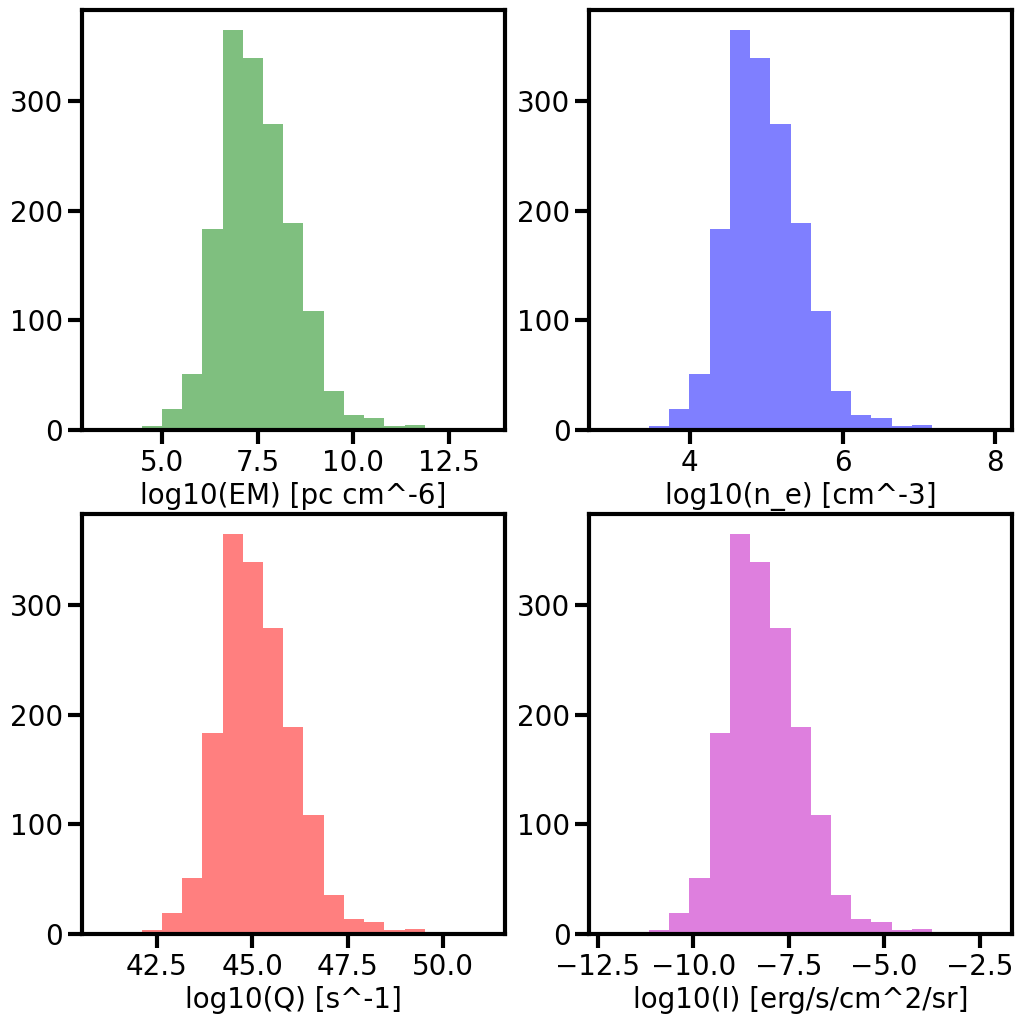

In [ ]:
fwhm_tbl = Table.read('/orange/adamginsburg/w51/jwst/reduction/fwhm_table.ecsv')
row = fwhm_tbl[fwhm_tbl['Filter'] == 'F187N']
fwhm_f187n = float(row['PSF FWHM (arcsec)'][0])
fwhm_f187n_au = (fwhm_f187n * 5400 *u.au).to(u.au)
print('fwhm_f187n:', fwhm_f187n, 'arcsec')
print('fwhm_f187n_au:', fwhm_f187n_au)
# convert Jy to EM
# get the frquency width of PaA from svo_fps
dereddend_excess = excess * 10**(0.4*av_estimate[mask]*ext(1/1.87/u.um))

tab_paa = SvoFps.get_transmission_data(f'JWST/NIRCAM.f187n')
wave_paa = tab_paa['Wavelength'] 
trans_paa = tab_paa['Transmission']
# get the frequency width of PaA from svo_fps
delta_lam = np.trapezoid(trans_paa / trans_paa.max(), wave_paa) * u.AA
print('delta_lam:', delta_lam)
delta_nu_paa= (const.c/1.87e-6/u.m**2 * delta_lam).to(u.Hz)
#F_paa = (excess*u.Jy * delta_nu).to(u.erg/u.s/u.cm**2)
#L_paa = (F_paa * 4 * np.pi * (5400*u.pc)**2).to(u.Lsun) 
#EM_from_paa = (L_paa / (const.h * const.c / (1.87e-6*u.m) * 3e-14*u.cm**3/u.s)).to(u.pc*u.cm**(-6))  #
#caseA_recomb_coeff = 4.18e-14 * u.cm**3/u.s  # Case A recombination coefficient for PaA at 10,000 K
#caseB_recomb_coeff = 3.14e-14 * u.cm**3/u.s  # Case B recombination coefficient for PaA at 10,000 K

I_paa = (dereddend_excess * u.Jy * delta_nu_paa/ (fwhm_f187n*u.arcsec)**2).to(u.erg/u.s/u.cm**2/u.sr)
S_paa = (I_paa / delta_nu_paa).to(u.MJy/u.sr)

#I_paa = (dereddend_excess * u.Jy * delta_nu/ (fwhm_f187n*u.arcsec)**2).to(u.erg/u.s/u.cm**2/u.sr)
#EM_from_IPaa = (4*np.pi*u.sr*I_paa / (const.h*const.c/(1.87e-6*u.m)*2.59e-13*u.cm**3/u.s)).to(u.pc*u.cm**(-6))
EM_from_IPaa = 1/6.4 * 1e6*S_paa.value * u.pc/u.cm**6 
density_from_paa = ((EM_from_IPaa / fwhm_f187n_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
print('density_from_paa:', density_from_paa)
Q_from_density = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_paa**2 * fwhm_f187n_au**3).to(u.s**-1).value) 
print(f'Q_from_density: {Q_from_density}')
fig = plt.figure(figsize=(12,12))
ax0 = fig.add_subplot(221)
ax0.hist(np.log10(EM_from_IPaa.value),bins=np.linspace(np.nanmin(np.log10(EM_from_IPaa.value)), np.nanmax(np.log10(EM_from_IPaa.value)), 20), color='g', alpha=0.5)
ax0.set_xlabel('log10(EM) [pc cm^-6]')
ax1 = fig.add_subplot(222)
ax1.hist(np.log10(density_from_paa.value),bins=np.linspace(np.nanmin(np.log10(density_from_paa.value)), np.nanmax(np.log10(density_from_paa.value)), 20), color='b', alpha=0.5)
ax1.set_xlabel('log10(n_e) [cm^-3]')
ax2 = fig.add_subplot(223)
ax2.hist(Q_from_density,bins=np.linspace(np.nanmin(Q_from_density), np.nanmax(Q_from_density), 20), color='r', alpha=0.5)
ax2.set_xlabel('log10(Q) [s^-1]')
ax3 = fig.add_subplot(224)
ax3.hist(np.log10(I_paa.value),bins=np.linspace(np.nanmin(np.log10(I_paa.value)), np.nanmax(np.log10(I_paa.value)), 20), color='m', alpha=0.5)
ax3.set_xlabel('log10(I) [erg/s/cm^2/sr]')

fwhm_f187n: 0.064 arcsec
fwhm_f187n_au: 345.6 AU
delta_lam: 236.59542237910327 Angstrom
density_from_paa: [            nan             nan             nan ... 169267.98765004
 212924.34091919             nan] 1 / cm3
Q_from_density: [        nan         nan         nan ... 45.63303547 45.83233643
         nan]


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/tmp/ipykernel_3958372/2540223084.py:35: RuntimeWarning: invalid value encountered in log10
  ax0.hist(np.log10(EM_from_IPaa.value),bins=np.linspace(np.nanmin(np.log10(EM_from_IPaa.value)), np.nanmax(np.log10(EM_from_IPaa.value)), 20), color='g', alpha=0.5)
/tmp/ipykernel_3958372/2540223084.py:44: RuntimeWarning: invalid value encountered in log10
  ax3.hist(np.log10(I_paa.value),bins=np.linspace(np.nanmin(np.log10(I_paa.value)), np.nanmax(np.log10(I_paa.value)), 20), color='m', alpha=0.5)


Text(0.5, 0, 'log10(I) [erg/s/cm^2/sr]')

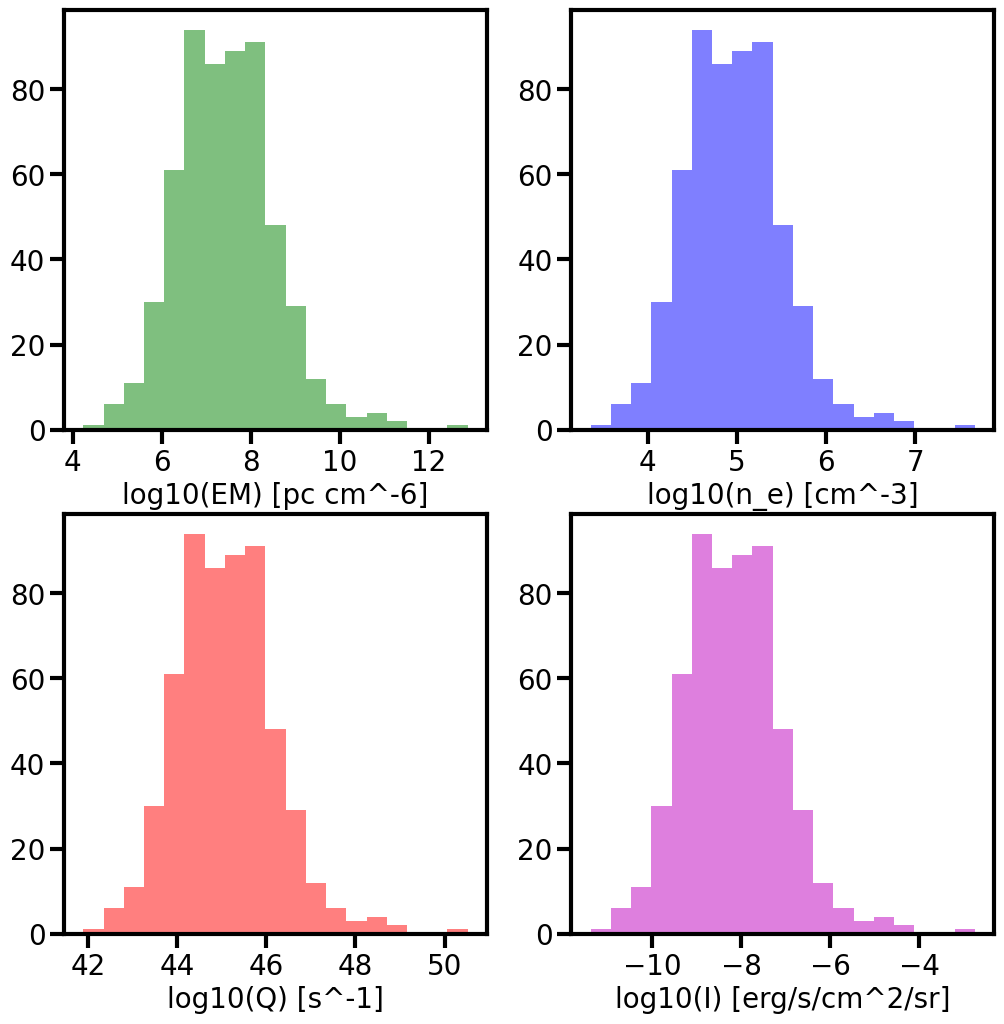

In [ ]:
fwhm_tbl = Table.read('/orange/adamginsburg/w51/jwst/reduction/fwhm_table.ecsv')
row = fwhm_tbl[fwhm_tbl['Filter'] == 'F187N']
fwhm_f187n = float(row['PSF FWHM (arcsec)'][0])
fwhm_f187n_au = (fwhm_f187n * 5400 *u.au).to(u.au)
print('fwhm_f187n:', fwhm_f187n, 'arcsec')
print('fwhm_f187n_au:', fwhm_f187n_au)
# convert Jy to EM
# get the frquency width of PaA from svo_fps
dereddend_excess = excess * 10**(0.4*av_estimate[mask]*ext(1/1.87/u.um))

tab_paa = SvoFps.get_transmission_data(f'JWST/NIRCAM.f187n')
wave_paa = tab_paa['Wavelength'] 
trans_paa = tab_paa['Transmission']
# get the frequency width of PaA from svo_fps
delta_lam = np.trapezoid(trans_paa / trans_paa.max(), wave_paa) * u.AA
print('delta_lam:', delta_lam)
delta_nu_paa= (const.c/1.87e-6/u.m**2 * delta_lam).to(u.Hz)
#F_paa = (excess*u.Jy * delta_nu).to(u.erg/u.s/u.cm**2)
#L_paa = (F_paa * 4 * np.pi * (5400*u.pc)**2).to(u.Lsun) 
#EM_from_paa = (L_paa / (const.h * const.c / (1.87e-6*u.m) * 3e-14*u.cm**3/u.s)).to(u.pc*u.cm**(-6))  #
#caseA_recomb_coeff = 4.18e-14 * u.cm**3/u.s  # Case A recombination coefficient for PaA at 10,000 K
#caseB_recomb_coeff = 3.14e-14 * u.cm**3/u.s  # Case B recombination coefficient for PaA at 10,000 K
I_paa = (dereddend_normalized_excess * u.Jy * delta_nu_paa/ (fwhm_f187n*u.arcsec)**2).to(u.erg/u.s/u.cm**2/u.sr)
S_paa = (I_paa / delta_nu_paa).to(u.MJy/u.sr)

#I_paa = (dereddend_excess * u.Jy * delta_nu/ (fwhm_f187n*u.arcsec)**2).to(u.erg/u.s/u.cm**2/u.sr)
#EM_from_IPaa = (4*np.pi*u.sr*I_paa / (const.h*const.c/(1.87e-6*u.m)*2.59e-13*u.cm**3/u.s)).to(u.pc*u.cm**(-6))
EM_from_IPaa = 1/6.4 * 1e6*S_paa.value * u.pc/u.cm**6 
density_from_paa = ((EM_from_IPaa / fwhm_f187n_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
print('density_from_paa:', density_from_paa)
Q_from_density = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_paa**2 * fwhm_f187n_au**3).to(u.s**-1).value) 
print(f'Q_from_density: {Q_from_density}')
fig = plt.figure(figsize=(12,12))
ax0 = fig.add_subplot(221)
ax0.hist(np.log10(EM_from_IPaa.value),bins=np.linspace(np.nanmin(np.log10(EM_from_IPaa.value)), np.nanmax(np.log10(EM_from_IPaa.value)), 20), color='g', alpha=0.5)
ax0.set_xlabel('log10(EM) [pc cm^-6]')
ax1 = fig.add_subplot(222)
ax1.hist(np.log10(density_from_paa.value),bins=np.linspace(np.nanmin(np.log10(density_from_paa.value)), np.nanmax(np.log10(density_from_paa.value)), 20), color='b', alpha=0.5)
ax1.set_xlabel('log10(n_e) [cm^-3]')
ax2 = fig.add_subplot(223)
ax2.hist(Q_from_density,bins=np.linspace(np.nanmin(Q_from_density), np.nanmax(Q_from_density), 20), color='r', alpha=0.5)
ax2.set_xlabel('log10(Q) [s^-1]')
ax3 = fig.add_subplot(224)
ax3.hist(np.log10(I_paa.value),bins=np.linspace(np.nanmin(np.log10(I_paa.value)), np.nanmax(np.log10(I_paa.value)), 20), color='m', alpha=0.5)
ax3.set_xlabel('log10(I) [erg/s/cm^2/sr]')

BIC for 1 components: 1747.5932452569032
BIC for 2 components: 1752.2272629072404
BIC for 3 components: 1760.0884332746382
BIC for 4 components: 1779.08942054305
Best number of components: 1


Text(0.5, 0, 'log10(Q) [s^-1]')

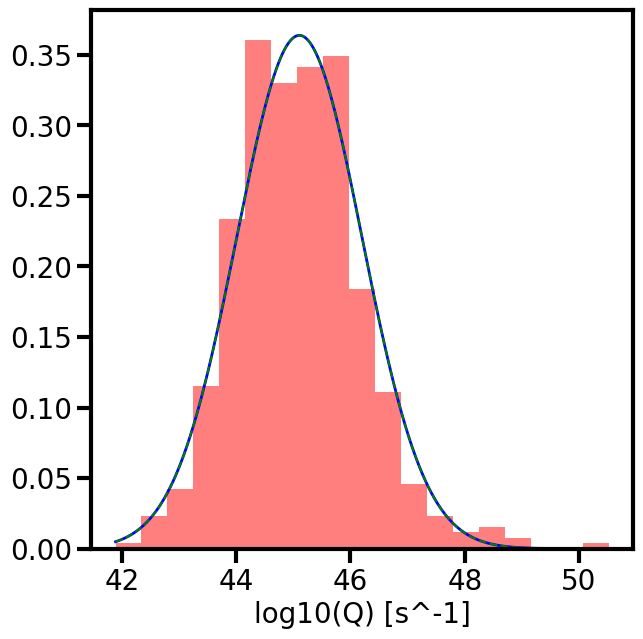

In [ ]:
# perform gaussian decomposition on log10(Q) distribution
best_bic = np.inf
best_n_components = 0

Q_from_density_finite = Q_from_density[np.isfinite(Q_from_density)]
for i in range(1, 5):
    from sklearn.mixture import GaussianMixture
    gmm = GaussianMixture(n_components=i, random_state=0)
    gmm.fit(Q_from_density_finite.reshape(-1, 1))
    bic = gmm.bic(Q_from_density_finite.reshape(-1, 1))
    print(f'BIC for {i} components: {bic}')
    if bic < best_bic:
        best_bic = bic
        best_n_components = i
print(f'Best number of components: {best_n_components}')

gmm_best = GaussianMixture(n_components=best_n_components, random_state=0)
gmm_best.fit(Q_from_density_finite.reshape(-1, 1))

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)
x = np.linspace(np.nanmin(Q_from_density), np.nanmax(Q_from_density), 1000)
logprob = gmm_best.score_samples(x.reshape(-1, 1))
pdf = np.exp(logprob)
ax.hist(Q_from_density, bins=np.linspace(np.nanmin(Q_from_density), np.nanmax(Q_from_density), 20), density=True, alpha=0.5, color='r')
ax.plot(x, pdf, color='b', linewidth=2)
for i in range(best_n_components):
    mean = gmm_best.means_[i][0]
    std = np.sqrt(gmm_best.covariances_[i][0][0])
    weight = gmm_best.weights_[i]
    ax.plot(x, weight * (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std)**2), color='g', linestyle='--')
ax.set_xlabel('log10(Q) [s^-1]')



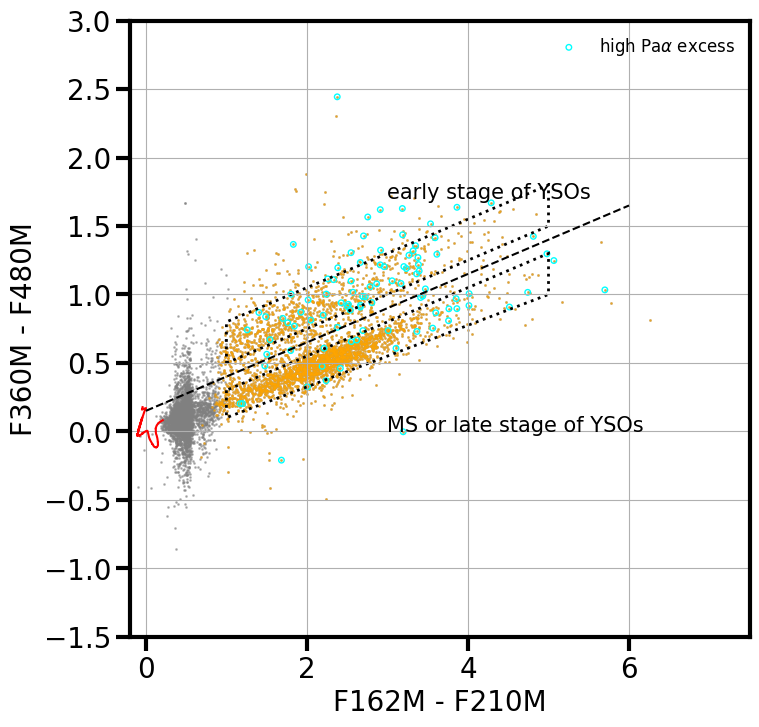

In [ ]:
idx_high_paa_excess = Q_from_density > 46
idx_red_sources = av_estimate > 12
# color color diagram using 162, 210, 360, 480
from matplotlib.path import Path
from matplotlib.patches import Polygon  

vertices_upper = [(1,0.5), (5,1.5), (5,1.8 ), (1, 0.8)]
vertices_lower = [(1,0.3), (1,0.1 ), (5,1), (5, 1.3)]


polygon1 = Polygon(vertices_upper, closed=True, fill=False, edgecolor='k', linewidth=2, ls='dotted')
polygon2 = Polygon(vertices_lower, closed=True, fill=False, edgecolor='k', linewidth=2, ls='dotted')

path1 = Path(vertices_upper)

color1 = f162m_mag[0] - f210m_mag[0]
color2 = f360m_mag[0]-f480m_mag[0]
idx1 = path1.contains_points(np.array([color1.value, color2.value]).T)

path2 = Path(vertices_lower)
idx2 = path2.contains_points(np.array([color1.value, color2.value]).T)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f162m_mag[0] - f210m_mag[0], f360m_mag[0]-f480m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f162m_mag[0][idx_red_sources] - f210m_mag[0][idx_red_sources],
        f360m_mag[0][idx_red_sources]-f480m_mag[0][idx_red_sources], s=1, c='orange', alpha=0.5)
ax.plot(parsec_mags['f162m'][age_idx] - parsec_mags['f210m'][age_idx], parsec_mags['f360m'][age_idx]-parsec_mags['f480m'][age_idx], color='r')


ax.scatter(f162m_mag[0][mask][idx_high_paa_excess] - f210m_mag[0][mask][idx_high_paa_excess],
        f360m_mag[0][mask][idx_high_paa_excess]-f480m_mag[0][mask][idx_high_paa_excess], edgecolors='cyan', facecolors='none', s=16, label=r'high Pa$\alpha$ excess')

ax.plot([0,6], [0.15, 1.65], c='k', ls='dashed')
ax.add_patch(polygon1)
ax.add_patch(polygon2)
ax.grid()
ax.text(3,1.7, 'early stage of YSOs', fontsize=15, color='k')
ax.text(3,0, 'MS or late stage of YSOs', fontsize=15, color='k')
plt.xlabel('F162M - F210M')
plt.ylabel('F360M - F480M')
ax.set_ylim(-1.5,3)
ax.set_xlim(-0.2,7.5)
ax.legend(fontsize=12, frameon=False)



      col40       
------------------
17.670968799114842
 17.43796879911484
 17.14896879911484
 17.12996879911484
16.994968799114844
16.830968799114842
 16.74296879911484
 16.46096879911484
16.307968799114843
 16.15496879911484
               ...
3.4059687991148415
3.2859687991148423
3.2679687991148416
3.1079687991148415
3.0309687991148415
2.9009687991148425
 2.842968799114841
2.7469687991148426
 2.622968799114842
2.5259687991148425
Length = 5863 rows
age_idx: [False False False ... False False False] idx_01msun: 1 idx_20msun: 217
1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
8.970550123456789 5.7899519999999995 8.970550123456789


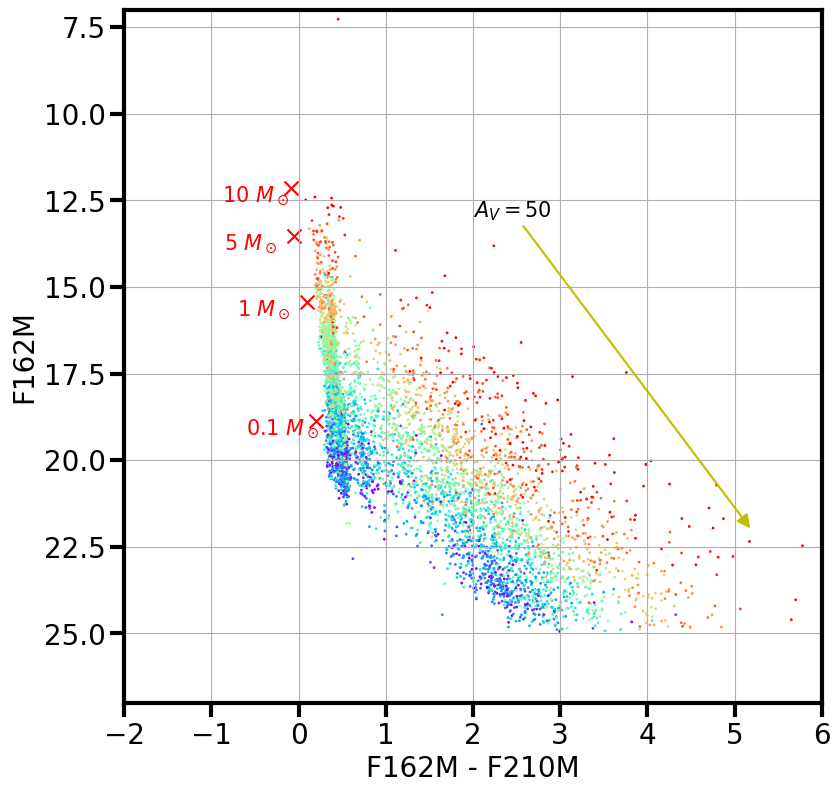

In [ ]:
color_for_points = bra_excess
norm = LogNorm(vmin=1e-7, vmax=1e-4)
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111)
ax.scatter(f162m_mag[0] - f210m_mag[0], f162m_mag[0], s=1,  c=color_for_points, alpha=1, norm=norm, cmap='rainbow')

age_idx = logage_av0 == 6
#ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx], F162Mmag_av0[age_idx],c='r')
cmap = plt.get_cmap('rainbow')

ext = CT06_MWLoc()
#plot isochrone with Av=10
#ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx]  + (ext(1/1.62/u.um) - ext(1/2.10/u.um))*5,
#F162Mmag_av0[age_idx]+(ext(1/1.62/u.um))*5, color='g')
#ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx]  + (ext(1/1.62/u.um) - ext(1/2.10/u.um))*10, 
#F162Mmag_av0[age_idx]+(ext(1/1.62/u.um))*10, color='b')

idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
print(F162Mmag_av0)
print('age_idx:', age_idx, 'idx_01msun:', idx_01msun, 'idx_20msun:', idx_20msun)
isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isocrhone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isocrhone_y_end = F162Mmag_av0[age_idx][idx_20msun]
color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isocrhone_y_start - color_slope * isochrone_x_start

A_K_scale = 5
A_V_scale = A_K_scale * 10
#ax.plot([isochrone_x_start, isochrone_x_end], [isocrhone_y_start, isocrhone_y_end], color='r', linestyle='--')
#ax1.plot([isochrone_x_start+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*A_V_scale, isochrone_x_end+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*A_V_scale], 
#[isocrhone_y_start+(ext(1/1.82/u.um))*A_V_scale, isocrhone_y_end+(ext(1/1.82/u.um))*A_V_scale], color='r', linestyle='--')
# extrapolate the linear part of the isochrone to the left and right by 0.5 mag in color

# and plot
#x_vals = np.array([-1, 2])
#y_vals = color_slope * x_vals + color_intercept
#ax.plot(x_vals, y_vals, color='r', linestyle='--')
for mass in [0.1, 1, 5, 10]:
    idx_mass = np.argmin(np.abs(mass_av0[age_idx]-mass))
    ax.scatter(F162Mmag_av0[age_idx][idx_mass] - F210Mmag_av0[age_idx][idx_mass], F162Mmag_av0[age_idx][idx_mass], color='r', marker='x', s=100)
    ax.annotate(f'{mass} $M_\odot$', (F162Mmag_av0[age_idx][idx_mass] - F210Mmag_av0[age_idx][idx_mass], F162Mmag_av0[age_idx][idx_mass]), textcoords="offset points", xytext=(-50,-10), ha='left', color='r', fontsize=15)
plot_extvec_cmd(ax, ('f162m', 'f210m'), ('f162m',), extvec_scale=50, start=(2,13))

#ax.text(-0.2, 11, r'$A_V$=0', fontsize=15, color='r')
#ax.text(0.1, 12, r'$A_V$=5', fontsize=15, color='g')
#ax.text(0.5, 13, r'$A_V$=10', fontsize=15, color='b')


#ax.text(1.7, 26.5, 'embedded sources in W51', fontsize=15, color='k')
#ax.text(-1.6, 26.5, 'foreground sources', fontsize=15, color='k')
#ax.annotate('embedded sources in W51', xy=(2, 26.5), xytext=(1.4, 26.5), ha='left', color='k', fontsize=15)
#ax.annotate('foreground sources', xy=(0, 26.5), xytext=(1, 26.5), ha='left', color='k', fontsize=15)
#ax.plot([0.4,1.3], [7, 27], c='k', ls='dashed')
# add colorbar as inset


ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
ax.set_ylim(27,7)
ax.set_xlim(-2,6)
ax.grid()
plt.show()


In [ ]:

y = f162m_mag[0].value
x = f162m_mag[0].value - f210m_mag[0].value
z= bra_excess
mask = (av_estimate > 12) & np.isfinite(x) & np.isfinite(y) & np.isfinite(z) & (z>0)
x= x[mask]
y= y[mask]
z= z[mask]
gp, good = robust_gp_surface(x, y, z)
X = np.column_stack((x, y))

log_model = gp.predict(X)
model = 10**log_model

excess = z - model


In [ ]:
xx = np.linspace(x.min(), x.max(), 200)
yy = np.linspace(12, 25, 200)

XX, YY = np.meshgrid(xx, yy)

grid = np.column_stack((XX.ravel(), YY.ravel()))

log_surface = gp.predict(grid)

surface = 10**log_surface
surface = surface.reshape(XX.shape)

fig = plt.figure(figsize=(14,21))
ax1 = fig.add_subplot(321)
ax1.scatter(x, y, s=10, c=z, alpha=0.5, norm=LogNorm(vmin=1e-7, vmax=1e-4), cmap='rainbow')
ax1.set_xlabel('F162M - F210M')
ax1.set_ylabel('F162M')
ax1.set_ylim(25,12)
ax1.set_xlim(0.5,6)


ax2 = fig.add_subplot(322)
c = ax2.pcolormesh(XX, YY, surface, cmap='rainbow', norm=LogNorm(vmin=1e-7, vmax=1e-4))
ax2.set_xlabel('F162M - F210M')
ax2.set_ylabel('F162M')
ax2.set_ylim(25,12)
ax2.set_xlim(0.5,6)

ax3= fig.add_subplot(323)
ax3.pcolormesh(XX, YY, surface, cmap='rainbow', norm=LogNorm(vmin=1e-7, vmax=1e-4))
ax3.scatter(x, y, s=10, c=z, alpha=1, edgecolor='black', norm=LogNorm(vmin=1e-7, vmax=1e-4), cmap='rainbow')
ax3.set_xlabel('F162M - F210M')
ax3.set_ylabel('F162M')
ax3.set_ylim(25,12)
ax3.set_xlim(0.5,6)

ax4 = fig.add_subplot(324)
# subtract the model from the data
excess = z - model
ax4.scatter(x, y, s=10, c=excess, alpha=0.5, norm=LogNorm(vmin=1e-7, vmax=1e-4), cmap='rainbow')
ax4.set_xlabel('F162M - F210M')
ax4.set_ylabel('F162M')
ax4.set_ylim(25,12)
ax4.set_xlim(0.5,6)

ax5 = fig.add_subplot(325)
# get the 10 closest neighbors in color-magnitude space and plot the median excess
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=10)
nn.fit(np.column_stack((x, y)))
distances, indices = nn.kneighbors(np.column_stack((x, y))) 

# and get the local standard deviation of the excess for those 10 neighbors
local_std = np.array([np.std(excess[indices[i]]) for i in range(len(x))])
normalized_excess = excess * (1 - local_std/excess)



ax5.scatter(x, y, s=10, c=normalized_excess, alpha=0.5, norm=LogNorm(vmin=1e-7, vmax=1e-4), cmap='rainbow')
ax5.set_xlabel('F162M - F210M')
ax5.set_ylabel('F162M')
ax5.set_ylim(25,12)
ax5.set_xlim(0.5,6)
    


    
cbar = fig.colorbar(c, ax=[ax1, ax2, ax3, ax4, ax5], orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label(r'Br$\alpha$ excess (Jy)', fontsize=20)




#save excess and normalized_excess to file
tab_bra = Table()
tab_bra['excess'] = excess
tab_bra['normalized_excess'] = normalized_excess
tab_bra.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/br_alpha_excess_cleancat.fits', overwrite=True)

ValueError: Input X contains NaN.
GaussianProcessRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Text(0, 0.5, 'Number of sources')

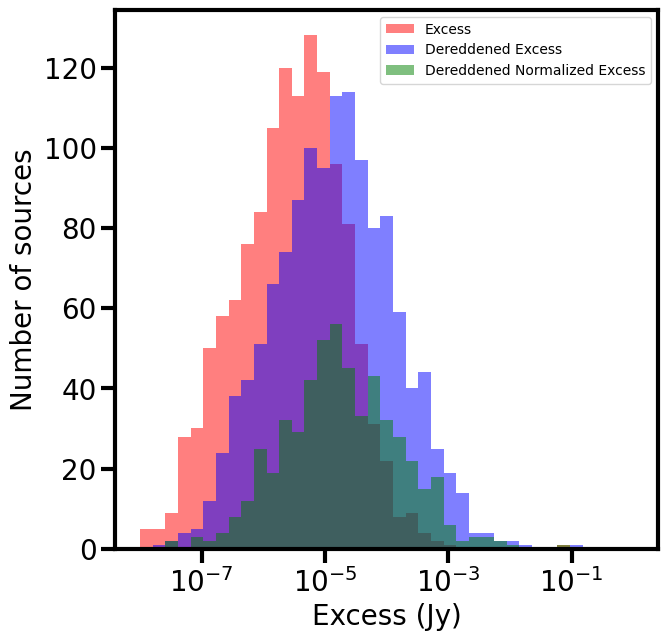

In [ ]:
# histogram of excess
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)

ax.hist(excess, bins=np.logspace(-8, 0, 40), color='r', alpha=0.5, label='Excess')
dereddend_excess = excess * 10**(0.4*av_estimate[mask]*ext(1/4.05/u.um))
dereddend_normalized_excess = normalized_excess * 10**(0.4*av_estimate[mask]*ext(1/4.05/u.um))
ax.hist(dereddend_excess, bins=np.logspace(-8, 0, 40), color='b', alpha=0.5, label='Dereddened Excess')
ax.hist(dereddend_normalized_excess, bins=np.logspace(-8, 0, 40), color='g', alpha=0.5, label='Dereddened Normalized Excess')
ax.legend()
ax.set_xscale('log')
ax.set_xlabel('Excess (Jy)')
ax.set_ylabel('Number of sources')

fwhm_f405n: 0.136 arcsec
fwhm_f405n_au: 734.4000000000001 AU
delta_lam: 454.94571260238206 Angstrom
density_from_bra: [            nan   9771.17127301  20853.49871422 ... 149501.70202883
 127391.17091661  11295.50826065] 1 / cm3
Q_from_density: [        nan 44.13785587 44.79632047 ... 46.50725489 46.36824127
 44.26377417]


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/tmp/ipykernel_3958372/1683904993.py:36: RuntimeWarning: invalid value encountered in log10
  ax0.hist(np.log10(EM_from_IBra.value),bins=np.linspace(np.nanmin(np.log10(EM_from_IBra.value)), np.nanmax(np.log10(EM_from_IBra.value)), 20), color='g', alpha=0.5)
/tmp/ipykernel_3958372/1683904993.py:45: RuntimeWarning: invalid value encountered in log10
  ax3.hist(np.log10(I_bra.value),bins=np.linspace(np.nanmin(np.log10(I_bra.value)), np.nanmax(np.log10(I_bra.value)), 20), color='m', alpha=0.5)


Text(0.5, 0, 'log10(I) [erg/s/cm^2/sr]')

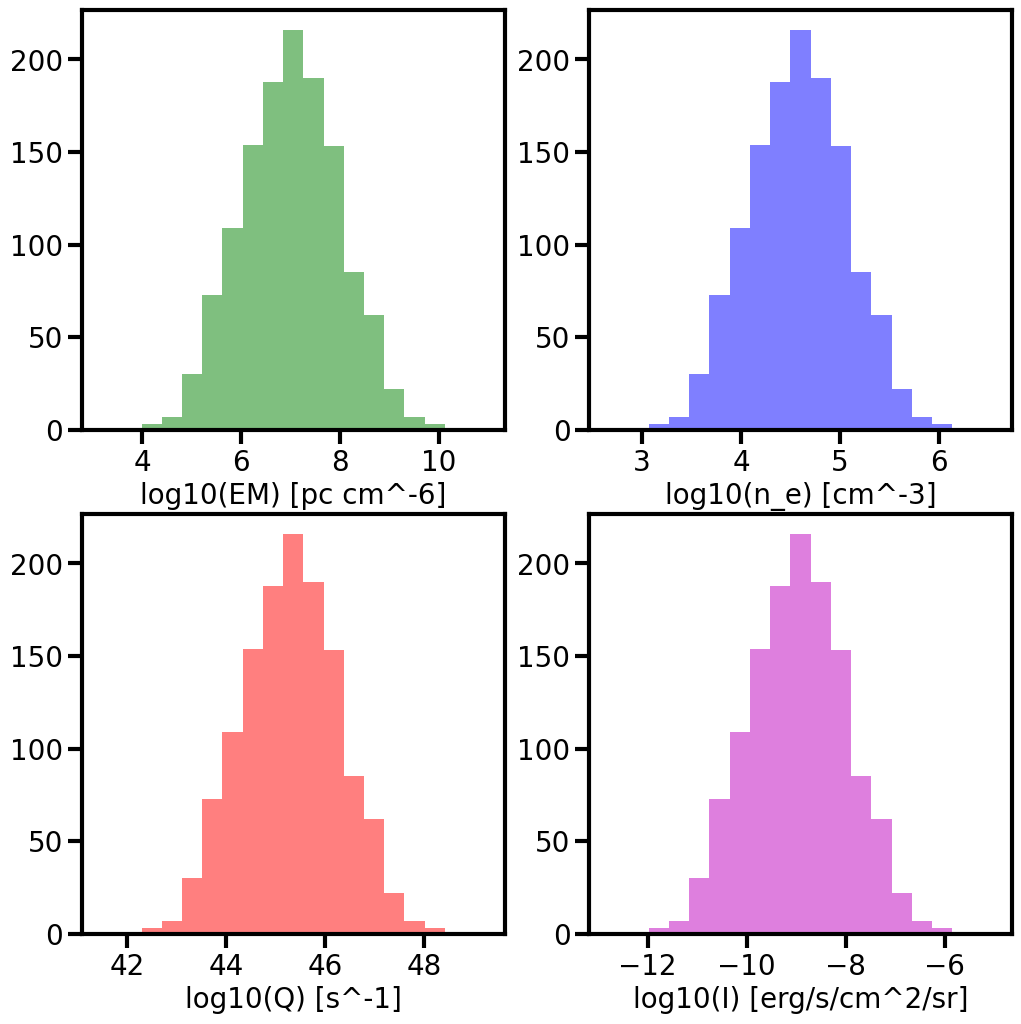

In [ ]:
fwhm_tbl = Table.read('/orange/adamginsburg/w51/jwst/reduction/fwhm_table.ecsv')
row = fwhm_tbl[fwhm_tbl['Filter'] == 'F405N']
fwhm_f405n = float(row['PSF FWHM (arcsec)'][0])
fwhm_f405n_au = (fwhm_f405n * 5400 *u.au).to(u.au)
print('fwhm_f405n:', fwhm_f405n, 'arcsec')
print('fwhm_f405n_au:', fwhm_f405n_au)
# convert Jy to EM
# get the frquency width of PaA from svo_fps
dereddend_excess = excess * 10**(0.4*av_estimate[mask]*ext(1/4.05/u.um))

tab_bra = SvoFps.get_transmission_data(f'JWST/NIRCAM.f405n')
wave_bra = tab_bra['Wavelength'] 
trans_bra = tab_bra['Transmission']
# get the frequency width of Bra from svo_fps
delta_lam = np.trapezoid(trans_bra / trans_bra.max(), wave_bra) * u.AA
print('delta_lam:', delta_lam)
delta_nu = (const.c/4.05e-6/u.m**2 * delta_lam).to(u.Hz)
#F_paa = (excess*u.Jy * delta_nu).to(u.erg/u.s/u.cm**2)
#L_paa = (F_paa * 4 * np.pi * (5400*u.pc)**2).to(u.Lsun) 
#EM_from_paa = (L_paa / (const.h * const.c / (4.05e-6*u.m) * 3e-14*u.cm**3/u.s)).to(u.pc*u.cm**(-6))  #
#caseA_recomb_coeff = 4.18e-14 * u.cm**3/u.s  # Case A recombination coefficient for PaA at 10,000 K
#caseB_recomb_coeff = 3.14e-14 * u.cm**3/u.s  # Case B recombination coefficient for PaA at 10,000 K

I_bra = (dereddend_excess * u.Jy * delta_nu/ (fwhm_f405n*u.arcsec)**2).to(u.erg/u.s/u.cm**2/u.sr)
S_bra = (I_bra / delta_nu).to(u.MJy/u.sr)

#EM_from_IBra = (4*np.pi*u.sr*I_bra / (const.h*const.c/(4.05e-6*u.m)*2.59e-13*u.cm**3/u.s)).to(u.pc*u.cm**(-6))
EM_from_IBra =  1/3.22 * 1e6*S_bra.value * u.pc/u.cm**6 

density_from_bra = ((EM_from_IBra / fwhm_f405n_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
print('density_from_bra:', density_from_bra)
Q_from_density = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_bra**2 * fwhm_f405n_au**3).to(u.s**-1).value) 
print(f'Q_from_density: {Q_from_density}')
fig = plt.figure(figsize=(12,12))
ax0 = fig.add_subplot(221)
ax0.hist(np.log10(EM_from_IBra.value),bins=np.linspace(np.nanmin(np.log10(EM_from_IBra.value)), np.nanmax(np.log10(EM_from_IBra.value)), 20), color='g', alpha=0.5)
ax0.set_xlabel('log10(EM) [pc cm^-6]')
ax1 = fig.add_subplot(222)
ax1.hist(np.log10(density_from_bra.value),bins=np.linspace(np.nanmin(np.log10(density_from_bra.value)), np.nanmax(np.log10(density_from_bra.value)), 20), color='b', alpha=0.5)
ax1.set_xlabel('log10(n_e) [cm^-3]')
ax2 = fig.add_subplot(223)
ax2.hist(Q_from_density,bins=np.linspace(np.nanmin(Q_from_density), np.nanmax(Q_from_density), 20), color='r', alpha=0.5)
ax2.set_xlabel('log10(Q) [s^-1]')
ax3 = fig.add_subplot(224)
ax3.hist(np.log10(I_bra.value),bins=np.linspace(np.nanmin(np.log10(I_bra.value)), np.nanmax(np.log10(I_bra.value)), 20), color='m', alpha=0.5)
ax3.set_xlabel('log10(I) [erg/s/cm^2/sr]')

fwhm_f405n: 0.136 arcsec
fwhm_f405n_au: 734.4000000000001 AU
delta_lam: 454.94571260238206 Angstrom
density_from_bra: [            nan             nan             nan ...  80590.64134219
 103163.3163799              nan] 1 / cm3
Q_from_density: [        nan         nan         nan ... 45.97053184 46.1850132
         nan]


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/tmp/ipykernel_3958372/3205200757.py:36: RuntimeWarning: invalid value encountered in log10
  ax0.hist(np.log10(EM_from_IBra.value),bins=np.linspace(np.nanmin(np.log10(EM_from_IBra.value)), np.nanmax(np.log10(EM_from_IBra.value)), 20), color='g', alpha=0.5)
/tmp/ipykernel_3958372/3205200757.py:45: RuntimeWarning: invalid value encountered in log10
  ax3.hist(np.log10(I_bra.value),bins=np.linspace(np.nanmin(np.log10(I_bra.value)), np.nanmax(np.log10(I_bra.value)), 20), color='m', alpha=0.5)


Text(0.5, 0, 'log10(I) [erg/s/cm^2/sr]')

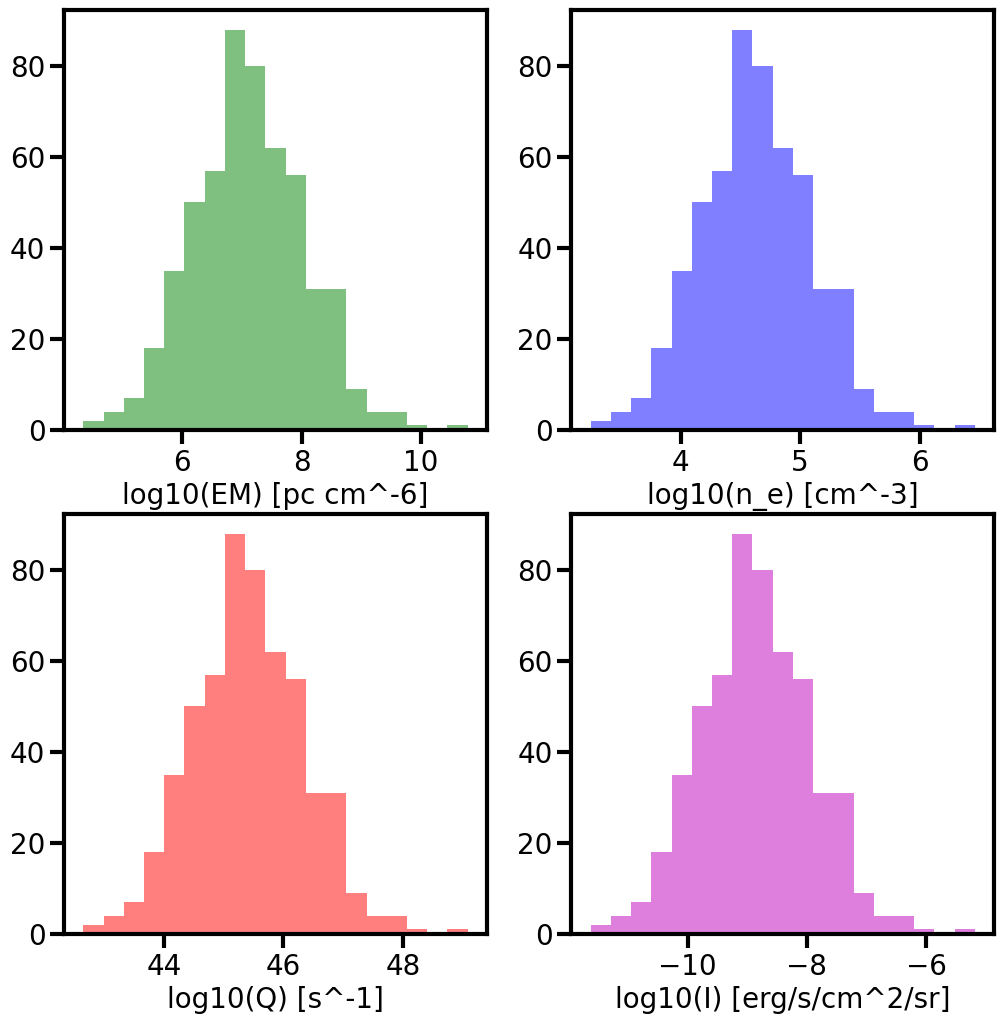

In [ ]:
fwhm_tbl = Table.read('/orange/adamginsburg/w51/jwst/reduction/fwhm_table.ecsv')
row = fwhm_tbl[fwhm_tbl['Filter'] == 'F405N']
fwhm_f405n = float(row['PSF FWHM (arcsec)'][0])
fwhm_f405n_au = (fwhm_f405n * 5400 *u.au).to(u.au)
print('fwhm_f405n:', fwhm_f405n, 'arcsec')
print('fwhm_f405n_au:', fwhm_f405n_au)
# convert Jy to EM
# get the frquency width of PaA from svo_fps
dereddend_excess = excess * 10**(0.4*av_estimate[mask]*ext(1/4.05/u.um))

tab_bra = SvoFps.get_transmission_data(f'JWST/NIRCAM.f405n')
wave_bra = tab_bra['Wavelength'] 
trans_bra = tab_bra['Transmission']
# get the frequency width of Bra from svo_fps
delta_lam = np.trapezoid(trans_bra / trans_bra.max(), wave_bra) * u.AA
print('delta_lam:', delta_lam)
delta_nu = (const.c/4.05e-6/u.m**2 * delta_lam).to(u.Hz)
#F_paa = (excess*u.Jy * delta_nu).to(u.erg/u.s/u.cm**2)
#L_paa = (F_paa * 4 * np.pi * (5400*u.pc)**2).to(u.Lsun) 
#EM_from_paa = (L_paa / (const.h * const.c / (4.05e-6*u.m) * 3e-14*u.cm**3/u.s)).to(u.pc*u.cm**(-6))  #
#caseA_recomb_coeff = 4.18e-14 * u.cm**3/u.s  # Case A recombination coefficient for PaA at 10,000 K
#caseB_recomb_coeff = 3.14e-14 * u.cm**3/u.s  # Case B recombination coefficient for PaA at 10,000 K

I_bra = (dereddend_normalized_excess * u.Jy * delta_nu/ (fwhm_f405n*u.arcsec)**2).to(u.erg/u.s/u.cm**2/u.sr)
S_bra = (I_bra / delta_nu).to(u.MJy/u.sr)

#EM_from_IBra = (4*np.pi*u.sr*I_bra / (const.h*const.c/(4.05e-6*u.m)*2.59e-13*u.cm**3/u.s)).to(u.pc*u.cm**(-6))
EM_from_IBra =  1/3.22 * 1e6*S_bra.value * u.pc/u.cm**6 

density_from_bra = ((EM_from_IBra / fwhm_f405n_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
print('density_from_bra:', density_from_bra)
Q_from_density = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_bra**2 * fwhm_f405n_au**3).to(u.s**-1).value) 
print(f'Q_from_density: {Q_from_density}')
fig = plt.figure(figsize=(12,12))
ax0 = fig.add_subplot(221)
ax0.hist(np.log10(EM_from_IBra.value),bins=np.linspace(np.nanmin(np.log10(EM_from_IBra.value)), np.nanmax(np.log10(EM_from_IBra.value)), 20), color='g', alpha=0.5)
ax0.set_xlabel('log10(EM) [pc cm^-6]')
ax1 = fig.add_subplot(222)
ax1.hist(np.log10(density_from_bra.value),bins=np.linspace(np.nanmin(np.log10(density_from_bra.value)), np.nanmax(np.log10(density_from_bra.value)), 20), color='b', alpha=0.5)
ax1.set_xlabel('log10(n_e) [cm^-3]')
ax2 = fig.add_subplot(223)
ax2.hist(Q_from_density,bins=np.linspace(np.nanmin(Q_from_density), np.nanmax(Q_from_density), 20), color='r', alpha=0.5)
ax2.set_xlabel('log10(Q) [s^-1]')
ax3 = fig.add_subplot(224)
ax3.hist(np.log10(I_bra.value),bins=np.linspace(np.nanmin(np.log10(I_bra.value)), np.nanmax(np.log10(I_bra.value)), 20), color='m', alpha=0.5)
ax3.set_xlabel('log10(I) [erg/s/cm^2/sr]')

In [ ]:
paa_excess_tab = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/pa_alpha_excess.fits')
paa_norm_excess = paa_excess_tab['normalized_excess']

fwhm_tbl = Table.read('/orange/adamginsburg/w51/jwst/reduction/fwhm_table.ecsv')
row = fwhm_tbl[fwhm_tbl['Filter'] == 'F187N']
fwhm_f187n = float(row['PSF FWHM (arcsec)'][0])
fwhm_f187n_au = (fwhm_f187n * 5400 *u.au).to(u.au)
print('fwhm_f187n:', fwhm_f187n, 'arcsec')
print('fwhm_f187n_au:', fwhm_f187n_au)
# convert Jy to EM
# get the frquency width of PaA from svo_fps
y = f162m_mag[0].value
x = f162m_mag[0].value - f210m_mag[0].value
mask_paa = (av_estimate > 12) & np.isfinite(x) & np.isfinite(y) & np.isfinite(paa_excess) & (paa_excess>0)

dereddend_paa_excess = paa_norm_aexcess * 10**(0.4*av_estimate[mask_paa]*ext(1/1.87/u.um))

tab_paa = SvoFps.get_transmission_data(f'JWST/NIRCAM.f187n')
wave_paa = tab_paa['Wavelength'] 
trans_paa = tab_paa['Transmission']
# get the frequency width of PaA from svo_fps
delta_lam = np.trapezoid(trans_paa / trans_paa.max(), wave_paa) * u.AA
print('delta_lam:', delta_lam)
delta_nu_paa= (const.c/1.87e-6/u.m**2 * delta_lam).to(u.Hz)
#F_paa = (excess*u.Jy * delta_nu).to(u.erg/u.s/u.cm**2)
#L_paa = (F_paa * 4 * np.pi * (5400*u.pc)**2).to(u.Lsun) 
#EM_from_paa = (L_paa / (const.h * const.c / (1.87e-6*u.m) * 3e-14*u.cm**3/u.s)).to(u.pc*u.cm**(-6))  #
#caseA_recomb_coeff = 4.18e-14 * u.cm**3/u.s  # Case A recombination coefficient for PaA at 10,000 K
#caseB_recomb_coeff = 3.14e-14 * u.cm**3/u.s  # Case B recombination coefficient for PaA at 10,000 K
I_paa = (dereddend_paa_excess * u.Jy * delta_nu_paa/ (fwhm_f187n*u.arcsec)**2).to(u.erg/u.s/u.cm**2/u.sr)
S_paa = (I_paa / delta_nu_paa).to(u.MJy/u.sr)
#I_paa = (dereddend_excess * u.Jy * delta_nu/ (fwhm_f187n*u.arcsec)**2).to(u.erg/u.s/u.cm**2/u.sr)
#EM_from_IPaa = (4*np.pi*u.sr*I_paa / (const.h*const.c/(1.87e-6*u.m)*2.59e-13*u.cm**3/u.s)).to(u.pc*u.cm**(-6))
EM_from_IPaa = 1/6.4 * 1e6*S_paa.value * u.pc/u.cm**6 
density_from_paa = ((EM_from_IPaa / fwhm_f187n_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
print('density_from_paa:', density_from_paa)
Q_from_density = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_paa**2 * fwhm_f187n_au**3).to(u.s**-1).value) 



paa_excess_tab['dereddend_paa_excess'] = dereddend_paa_excess
paa_excess_tab['I_paa'] = I_paa
paa_excess_tab['S_paa'] = S_paa
paa_excess_tab['EM_from_IPaa'] = EM_from_IPaa
paa_excess_tab['density_from_paa'] = density_from_paa
paa_excess_tab['Q_from_density'] = Q_from_density





fwhm_f187n: 0.064 arcsec
fwhm_f187n_au: 345.6 AU


NameError: name 'paa_norm_aexcess' is not defined

In [ ]:


bra_excess_tab = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/br_alpha_excess.fits')
bra_norm_excess = bra_excess_tab['normalized_excess']


fwhm_tbl = Table.read('/orange/adamginsburg/w51/jwst/reduction/fwhm_table.ecsv')
row = fwhm_tbl[fwhm_tbl['Filter'] == 'F405N']
fwhm_f405n = float(row['PSF FWHM (arcsec)'][0])
fwhm_f405n_au = (fwhm_f405n * 5400 *u.au).to(u.au)
print('fwhm_f405n:', fwhm_f405n, 'arcsec')
print('fwhm_f405n_au:', fwhm_f405n_au)
# convert Jy to EM
# get the frquency width of PaA from svo_fps
mask_bra = (av_estimate > 12) & np.isfinite(x) & np.isfinite(y) & np.isfinite(bra_excess) & (bra_excess>0)

dereddend_bra_excess = bra_norm_excess * 10**(0.4*av_estimate[mask_bra]*ext(1/4.05/u.um))
I_bra = (dereddend_bra_excess * u.Jy * delta_nu/ (fwhm_f405n*u.arcsec)**2).to(u.erg/u.s/u.cm**2/u.sr)
S_bra = (I_bra / delta_nu).to(u.MJy/u.sr)
EM_from_IBra = 1/6.4 * 1e6*S_bra.value * u.pc/u.cm**6 
density_from_bra = ((EM_from_IBra / fwhm_f405n_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
print('density_from_bra:', density_from_bra)
Q_from_density = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_bra**2 * fwhm_f405n_au**3).to(u.s**-1).value) 

bra_excess_tab['dereddend_bra_excess'] = dereddend_bra_excess
bra_excess_tab['I_bra'] = I_bra
bra_excess_tab['S_bra'] = S_bra
bra_excess_tab['EM_from_IBra'] = EM_from_IBra
bra_excess_tab['density_from_bra'] = density_from_bra
bra_excess_tab['Q_from_density'] = Q_from_density




fwhm_f405n: 0.136 arcsec
fwhm_f405n_au: 734.4000000000001 AU
density_from_bra: [           nan            nan            nan ...            nan
 14977.01137375 63701.92281594] 1 / cm3


Common indices: [    3     8    19 ... 23930 27231 31383]


/tmp/ipykernel_2656524/1428517080.py:15: RuntimeWarning: invalid value encountered in log10
  ax0.scatter(np.log10(EM_from_IPaa.value[idx_paa_to_common]), np.log10(EM_from_IBra.value[idx_bra_to_common]), s=1, c='k', alpha=0.5)
/tmp/ipykernel_2656524/1428517080.py:16: RuntimeWarning: invalid value encountered in log10
  ax0.plot([np.nanmin(np.log10(EM_from_IPaa.value[idx_paa_to_common])), np.nanmax(np.log10(EM_from_IPaa.value[idx_paa_to_common]))],
/tmp/ipykernel_2656524/1428517080.py:17: RuntimeWarning: invalid value encountered in log10
  [np.nanmin(np.log10(EM_from_IPaa.value[idx_paa_to_common])), np.nanmax(np.log10(EM_from_IPaa.value[idx_paa_to_common]))], ls='dashed', c='r')
/tmp/ipykernel_2656524/1428517080.py:29: RuntimeWarning: invalid value encountered in log10
  ax3.scatter(np.log10(I_paa.value)[idx_paa_to_common], np.log10(I_bra.value)[idx_bra_to_common], s=1, c='k', alpha=0.5)


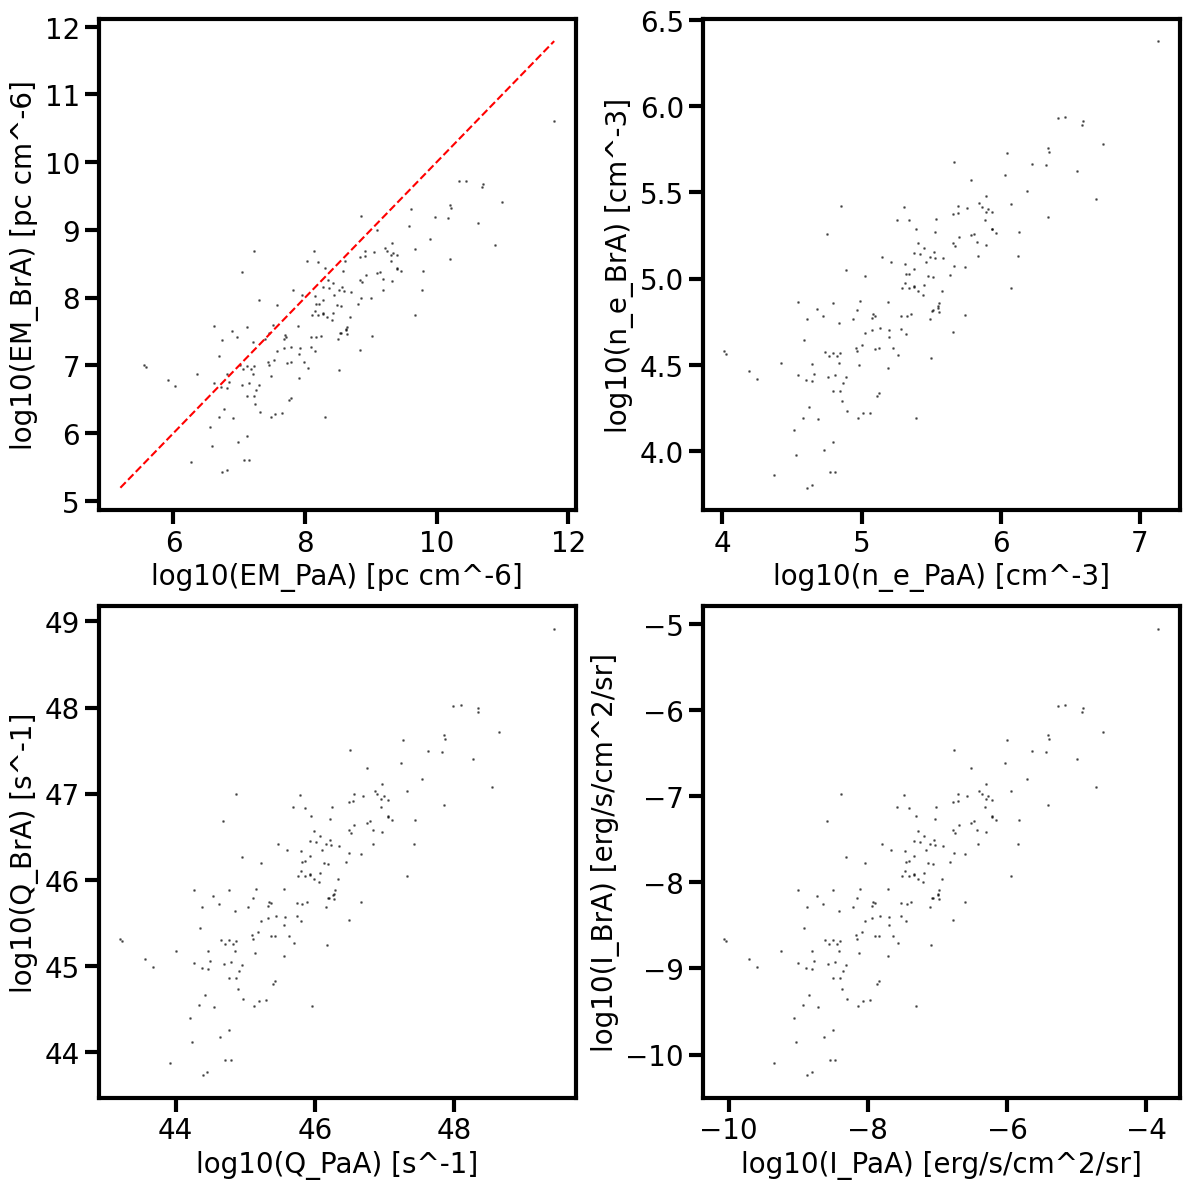

In [ ]:
# get the common element of mask_paa and mask_bra and compare the density_from_paa and density_from_bra
common_idx = np.intersect1d(np.where(mask_paa)[0], np.where(mask_bra)[0])

# get the index of np.where(mask_paa)[0] that corresponds to the common_idx
idx_paa_to_common = np.where(np.isin(np.where(mask_paa)[0], common_idx))[0]
# get the index of np.where(mask_bra)[0] that corresponds to the common_idx
idx_bra_to_common = np.where(np.isin(np.where(mask_bra)[0], common_idx))[0]




print('Common indices:', common_idx)
fig = plt.figure(figsize=(12,12))
ax0 = fig.add_subplot(221)
ax0.scatter(np.log10(EM_from_IPaa.value[idx_paa_to_common]), np.log10(EM_from_IBra.value[idx_bra_to_common]), s=1, c='k', alpha=0.5)
ax0.plot([np.nanmin(np.log10(EM_from_IPaa.value[idx_paa_to_common])), np.nanmax(np.log10(EM_from_IPaa.value[idx_paa_to_common]))],
         [np.nanmin(np.log10(EM_from_IPaa.value[idx_paa_to_common])), np.nanmax(np.log10(EM_from_IPaa.value[idx_paa_to_common]))], ls='dashed', c='r')
ax0.set_xlabel('log10(EM_PaA) [pc cm^-6]')
ax0.set_ylabel('log10(EM_BrA) [pc cm^-6]')
ax1 = fig.add_subplot(222)
ax1.scatter(np.log10(density_from_paa.value[idx_paa_to_common]), np.log10(density_from_bra.value[idx_bra_to_common]), s=1, c='k', alpha=0.5)
ax1.set_xlabel('log10(n_e_PaA) [cm^-3]')
ax1.set_ylabel('log10(n_e_BrA) [cm^-3]')
ax2 = fig.add_subplot(223)
ax2.scatter(paa_excess_tab['Q_from_density'][idx_paa_to_common], bra_excess_tab['Q_from_density'][idx_bra_to_common], s=1, c='k', alpha=0.5)
ax2.set_xlabel('log10(Q_PaA) [s^-1]')
ax2.set_ylabel('log10(Q_BrA) [s^-1]')   
ax3 = fig.add_subplot(224)
ax3.scatter(np.log10(I_paa.value)[idx_paa_to_common], np.log10(I_bra.value)[idx_bra_to_common], s=1, c='k', alpha=0.5)
ax3.set_xlabel('log10(I_PaA) [erg/s/cm^2/sr]')
ax3.set_ylabel('log10(I_BrA) [erg/s/cm^2/sr]')

plt.tight_layout()